In [1]:
from uphate.nn import TransformerConfig, Transformer
from phate import PHATE
from phate.tree import gen_dla
from flax import nnx
import jax.numpy as jnp

import matplotlib.pyplot as plt

ERROR:2025-12-08 13:44:16,205:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/cpsc4844_tl855/project_cpsc4844/cpsc4844_tl855/uPHATE/.venv/lib64/python3.11/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/cpsc4844_tl855/project_cpsc4844/cpsc4844_tl855/uPHATE/.venv/lib64/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/cpsc4844_tl855/project_cpsc4844/cpsc4844_tl855/uPHATE/.venv/lib64/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


Calculating PHATE...
  Running PHATE on 600 observations and 20 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
    Calculated affinities in 0.02 seconds.
  Calculated graph and diffusion operator in 0.03 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.12 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.26 seconds.
Calculated PHATE in 1.42 seconds.


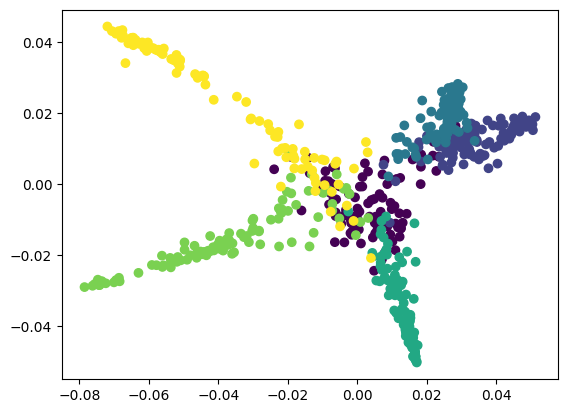

In [10]:
X, labels = gen_dla(20, 6, 100)
X -= X.mean(axis=0, keepdims=True)
X /= X.std(axis=0, keepdims=True)
X_phate = PHATE(knn=5, t=20, decay=15).fit_transform(X)
plt.scatter(*X_phate.T, c=labels)

In [12]:
config = TransformerConfig()
rngs = nnx.Rngs(0)
model = Transformer(X.shape[1], X_phate.shape[1], rngs=rngs, config=config)

In [13]:
model(jnp.array(X))

Array([[-0.577087  ,  0.67687327],
       [-0.57708734,  0.67687285],
       [-0.5770872 ,  0.6768732 ],
       ...,
       [-0.57708776,  0.67687285],
       [-0.57708716,  0.67687285],
       [-0.57708704,  0.6768733 ]], dtype=float32)

In [17]:
import optax

learning_rate = 0.005
momentum = 0.9

optimizer = nnx.Optimizer(
  model, optax.adamw(learning_rate, momentum), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  loss=nnx.metrics.Average('loss'),
)

nnx.display(optimizer)

In [18]:
import jax


def loss_fn(model: Transformer, X: jax.Array, X_phate: jax.Array):
    predictions = model(X)
    loss = optax.squared_error(predictions, X_phate).mean()
    return loss, predictions


@nnx.jit
def train_step(
    model: Transformer,
    optimizer: nnx.Optimizer,
    metrics: nnx.MultiMetric,
    X: jax.Array,
    X_phate: jax.Array,
):
    """Train for a single step."""
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, emb), grads = grad_fn(model, X, X_phate)
    metrics.update(loss=loss)
    optimizer.update(grads)

In [20]:
for step in range(5):
    # Run the optimization for one step and make a stateful update to the following:
    # - The train state's model parameters
    # - The optimizer state
    # - The training loss and accuracy batch metrics
    model.train()  # Switch to train mode
    train_step(model, optimizer, metrics, jnp.array(X), jnp.array(X_phate))

    for metric, value in metrics.compute().items():
        print(f"{metric}: {value:.4f}")

loss: 83.0363
loss: 79.1818
loss: 72.0267
loss: 65.3029
loss: 59.4048
